In [1]:
import os
import librosa
import math
import json 
import matplotlib.pyplot as plt
import numpy as np


In [2]:
dataset_path = r"D:/web/cnn_clasification/archive/Data/genres_original"
json_path = r"data.json"
SAMPLE_RATE = 22050
DURATION = 30
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

In [3]:
def save_mfcc(dataset_path, json_path, n_mfcc=13, n_fft=2048,
             hop_length=512, num_segments=5):
    # Data storage dictionary
    data = {
        "mapping": [],
        "mfcc": [],
        "labels": [],
    }
    samples_ps = int(SAMPLES_PER_TRACK/num_segments) # ps = per segment
    expected_vects_ps = math.ceil(samples_ps/hop_length)
    
    # loop through all the genres
    for i, (dirpath, dirnames, filenames) in enumerate(os.walk(dataset_path)):
        # ensuring not at root
        if dirpath is not dataset_path:
            # save the semantic label
            dirpath_comp = dirpath.split("/")
            semantic_label = dirpath_comp[-1]
            data["mapping"].append(semantic_label)
            print(f"Processing: {semantic_label}")
            
            # process files for specific genre
            for f in filenames:
                if(f==str("anjing1.wav")):
                    # As librosa only read files <1Mb
                    continue
                else:
                    # load audio file
                    file_path = os.path.join(dirpath, f)
                    signal,sr = librosa.load(file_path,sr=SAMPLE_RATE)
                    for s in range(num_segments):
                        start_sample = samples_ps * s
                        finish_sample = start_sample + samples_ps

                        mfcc = librosa.feature.mfcc(
                                y=signal[start_sample:finish_sample],
                                sr=sr,
                                n_fft=n_fft,
                                n_mfcc=n_mfcc,
                                hop_length=hop_length
                        )


                        mfcc = mfcc.T

                        # store mfcc if it has expected length 
                        if len(mfcc)==expected_vects_ps:
                            data["mfcc"].append(mfcc.tolist())
                            data["labels"].append(i-1)
                            print(f"{file_path}, segment: {s+1}")

    with open(json_path,"w") as f:
        json.dump(data,f,indent=4)

In [4]:
from IPython.display import clear_output

In [5]:
save_mfcc(dataset_path,json_path,num_segments=20)
clear_output()

In [6]:
filepath = r"D:/web/cnn_clasification/archive/Data/genres_original/audioanjing/anjing2"

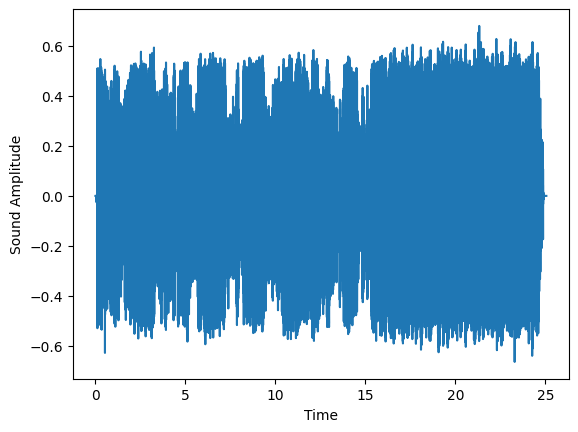

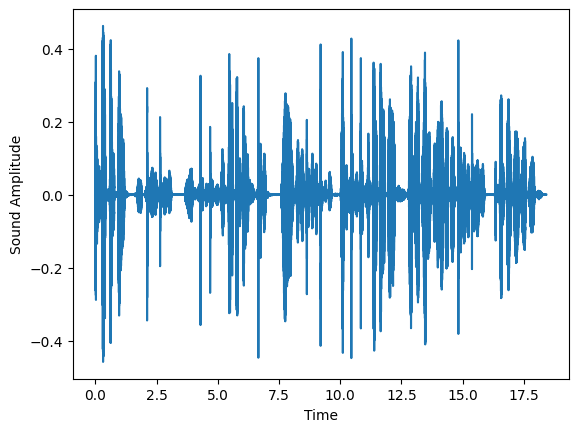

In [7]:
for i in range(2):
    audio, sfreq = librosa.load(filepath+str(i)+".wav")
    time = np.arange(0, len(audio))/sfreq
    plt.plot(time,audio)
    plt.xlabel("Time")
    plt.ylabel("Sound Amplitude")
    plt.show()

In [8]:
import json
import numpy as np

In [9]:
# load data
def load_data(dataset_path):
    with open(dataset_path,"r") as f:
        data = json.load(f)
    
    # Convert list to numpy arrays
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])    
    
    return inputs,targets

In [10]:
inputs,targets = load_data(r"D:/web/cnn_clasification/data.json")

In [11]:
# splitting the data
from sklearn.model_selection import train_test_split

input_train, input_test, target_train, target_test = train_test_split(inputs, targets, test_size=0.3)
print(input_train.shape, target_train.shape)

(2341, 65, 13) (2341,)


In [12]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *

In [13]:
model = Sequential()

model.add(Flatten(input_shape=(inputs.shape[1],inputs.shape[2])))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 845)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         433,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 581,578 (2.22 MB)

 Trainable params: 581,578 (2.22 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras import optimizers
adam = optimizers.Adam(learning_rate=1e-4)

In [15]:
model.compile(optimizer=adam,
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

In [16]:
model.compile(optimizer=adam,
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

hist = model.fit(input_train, target_train,
                 validation_data = (input_test,target_test),
                 epochs = 40,
                 batch_size = 32)
clear_output()

In [17]:
def plot_history(hist):
    plt.figure(figsize=(20,15))
    fig, axs = plt.subplots(2)
    # accuracy subplot
    axs[0].plot(hist.history["accuracy"], label="train accuracy")
    axs[0].plot(hist.history["val_accuracy"], label="test accuracy")    
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy eval")
    
    # Error subplot
    axs[1].plot(hist.history["loss"], label="train error")
    axs[1].plot(hist.history["val_loss"], label="test error")    
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Error eval")
    
    plt.show()

<Figure size 2000x1500 with 0 Axes>

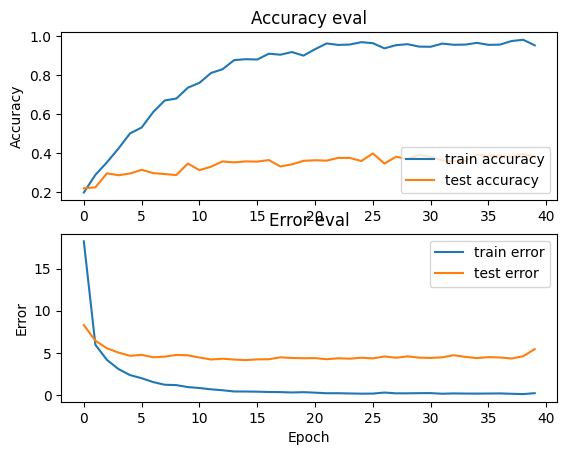

In [18]:
plot_history(hist)

In [19]:
test_error, test_accuracy = model.evaluate(input_test, target_test, verbose=1)
print(f"Test accuracy: {test_accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3835 - loss: 5.4566
Test accuracy: 0.38346612453460693


In [20]:
import tensorflow.keras as keras

In [21]:
# Overfitting
model = Sequential()

model.add(Flatten(input_shape=(inputs.shape[1],inputs.shape[2])))
model.add(Dense(512, activation='relu', kernel_regularizer = keras.regularizers.l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu', kernel_regularizer = keras.regularizers.l2(0.003)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu', kernel_regularizer = keras.regularizers.l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 845)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         433,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 583,338 (2.23 MB)

 Trainable params: 583,338 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras import optimizers

adam = optimizers.Adam(learning_rate=1e-4)  # gunakan learning_rate, bukan lr
model.compile(optimizer=adam,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

hist = model.fit(
    input_train, target_train,
    validation_data=(input_test, target_test),
    epochs=40,
    batch_size=32
)

Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.1141 - loss: 47.5182 - val_accuracy: 0.1484 - val_loss: 8.7936
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.1273 - loss: 20.2971 - val_accuracy: 0.1952 - val_loss: 6.4455
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1273 - loss: 14.0581 - val_accuracy: 0.1912 - val_loss: 5.7973
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1346 - loss: 11.0246 - val_accuracy: 0.1514 - val_loss: 5.0823
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1354 - loss: 8.5372 - val_accuracy: 0.2470 - val_loss: 4.9053
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1452 - loss: 7.2824 - val_accuracy: 0.2859 - val_loss: 4.8970
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1709 - loss: 6.4967 - val_accuracy: 0.3227 - val_loss: 4.8794
Epoch 8/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1845 - loss: 6.0712 - val_accuracy: 0.3376

<Figure size 2000x1500 with 0 Axes>

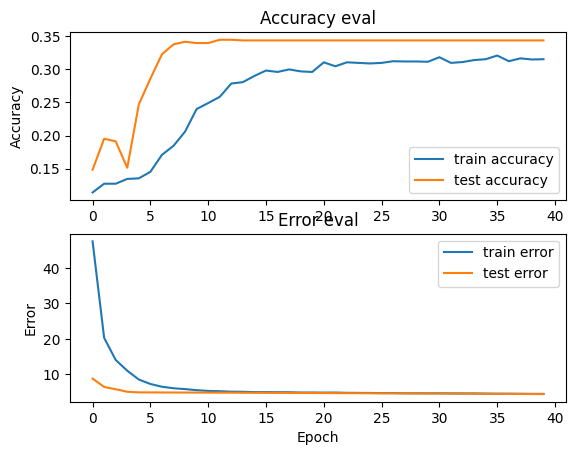

In [23]:
plot_history(hist)

In [24]:
test_error, test_accuracy = model.evaluate(input_test, target_test, verbose=1)
print(f"Test accuracy: {test_accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3436 - loss: 4.4266
Test accuracy: 0.3436254858970642


In [25]:
def prepare_dataset(test_size, validation_size):
    X,y = load_data(r"./data.json")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = validation_size)
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_dataset(0.25, 0.2)

In [27]:
input_shape = (X_train.shape[1],X_train.shape[2],X_train.shape[3])
print(input_shape)

(65, 13, 1)


In [28]:
model = Sequential()
model.add(Conv2D(64, (3, 3), activation = "relu", input_shape = input_shape))
model.add(MaxPool2D((3, 3), strides=(2, 2), padding="same"))
model.add(BatchNormalization())

model.add(Conv2D(32, (3, 3), activation = "relu"))
model.add(MaxPool2D((3, 3), strides=(2, 2), padding="same"))
model.add(BatchNormalization())

model.add(Conv2D(32, (2, 2), activation = "relu"))
model.add(MaxPool2D((2, 2), strides=(2, 2), padding="same"))
model.add(BatchNormalization())

model.add(Conv2D(16, (1, 1), activation = "relu"))
model.add(MaxPool2D((1, 1), strides=(2, 2), padding="same"))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(10, activation="softmax"))

model.summary()

C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 63, 11, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 6, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 6, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 30, 4, 32)           │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 15, 2, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 15, 2, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 1, 32)           │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 1, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7, 1, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 1, 16)            │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 1, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 4, 1, 16)            │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,146 (113.85 KB)

 Trainable params: 28,858 (112.73 KB)

 Non-trainable params: 288 (1.12 KB)

In [31]:
from tensorflow.keras import optimizers

adam = optimizers.Adam(learning_rate=1e-4) 
model.compile(optimizer=adam,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

hist = model.fit(X_train, y_train,
                 validation_data = (X_val, y_val),
                 epochs = 40,
                 batch_size = 32)

Epoch 1/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.5274 - loss: 1.3636 - val_accuracy: 0.3845 - val_loss: 1.7449
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5404 - loss: 1.3321 - val_accuracy: 0.4004 - val_loss: 1.7191
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5424 - loss: 1.3177 - val_accuracy: 0.3964 - val_loss: 1.7812
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5469 - loss: 1.2892 - val_accuracy: 0.4104 - val_loss: 1.7170
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5489 - loss: 1.2935 - val_accuracy: 0.4183 - val_loss: 1.7416
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5593 - loss: 1.2917 - val_accuracy: 0.4004 - val_loss: 1.7387
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5633 - loss: 1.2838 - val_accuracy: 0.3904 - val_loss: 1.7461
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5788 - loss: 1.2351 - val_accuracy: 0.4044 - v

<Figure size 2000x1500 with 0 Axes>

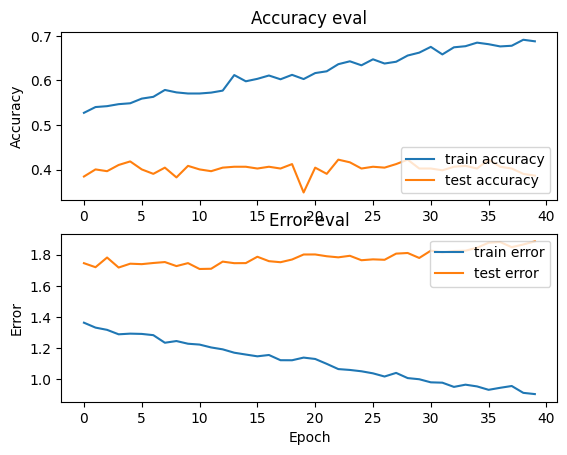

In [32]:
plot_history(hist)

In [33]:
test_error, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {test_accuracy}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3895 - loss: 1.9135
Test accuracy: 0.38948625326156616


In [34]:
def predict(model, X, y):
    X = X[np.newaxis,...]
    prediction = model.predict(X)
    predicted_index = np.argmax(prediction, axis=1)
    print(f"Expected index: {y}, Predicted index: {predicted_index}")

In [35]:
predict(model, X_test[10], y_test[10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
Expected index: 3, Predicted index: [5]


In [36]:
# ==== Setup & data split ====
import numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers

# reproducibility
seed = 42
np.random.seed(seed); tf.random.set_seed(seed)

# --- Ganti X, y dengan punyamu ---
# X: (n_samples, n_features), y: (n_samples,) label integer
# X, y = ... 

num_classes = int(np.max(y)) + 1

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

# Standardisasi fitur (fit di train saja)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# Class weights (berguna jika kelas tidak seimbang)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

# ==== Model ====
def build_mlp(input_dim, num_classes, l2w=1e-4, drop=0.4, noise_std=0.02):
    inp = layers.Input(shape=(input_dim,))
    x = layers.GaussianNoise(noise_std)(inp)                  # regularisasi halus
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop)(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop)(x)

    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

model = build_mlp(X_train.shape[1], num_classes)

# Optimizer + compile
adam = optimizers.Adam(learning_rate=1e-3)   # mulai agak tinggi, nanti auto-turun
model.compile(optimizer=adam,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# ==== Callbacks: EarlyStopping + ReduceLROnPlateau ====
cbs = [
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, verbose=1, min_lr=1e-6
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=12, verbose=1, restore_best_weights=True
    )
]

# ==== Train ====
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=32,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)

# ==== Eval & report ====
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_val_pred = np.argmax(model.predict(X_val), axis=1)
print("Val accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, digits=4))

# ==== Plot util ====
import matplotlib.pyplot as plt

def plot_history(h):
    # Accuracy
    plt.figure(figsize=(9,6))
    plt.plot(h.history["accuracy"], label="train acc")
    plt.plot(h.history["val_accuracy"], label="val acc")
    plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend(); plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(9,6))
    plt.plot(h.history["loss"], label="train loss")
    plt.plot(h.history["val_loss"], label="val loss")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    plt.show()

plot_history(hist)


NameError: name 'y' is not defined

In [37]:
from tensorflow.keras import layers, models, regularizers, optimizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Standardisasi (jika belum)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

num_classes = int(np.max(y_train)) + 1
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}

# Model arsitektur
def build_mlp(input_dim, num_classes, l2w=1e-4, drop=0.4, noise_std=0.02):
    inp = layers.Input(shape=(input_dim,))
    x = layers.GaussianNoise(noise_std)(inp)
    for units in [256, 128, 64]:
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=regularizers.l2(l2w))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(drop)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

model = build_mlp(X_train_s.shape[1], num_classes)

adam = optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6),
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

hist = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)


ValueError: Found array with dim 4, while dim <= 2 is required by StandardScaler.

Memuat cache fitur: mfcc_features_cache.npz → X:(25, 240), y:(25,), kelas:1
Shape fitur: (25, 240) | Kelas: 1 ['audioanjing']
Class weights: {0: 1.0}


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 240)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gaussian_noise_1 (GaussianNoise)     │ (None, 240)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 256)                 │          61,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104,705 (409.00 KB)

 Trainable params: 103,809 (405.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0000e+00 - loss: 0.0504
Epoch 1: val_loss improved from None to 0.04937, saving model to best_dnn_mfcc.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.0000e+00 - loss: 0.0504 - val_accuracy: 0.0000e+00 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0000e+00 - loss: 0.0494
Epoch 2: val_loss improved from 0.04937 to 0.04833, saving model to best_dnn_mfcc.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.0000e+00 - loss: 0.0494 - val_accuracy: 0.0000e+00 - val_loss: 0.0483 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0000e+00 - loss: 0.0483
Epoch 3: val_loss improved from 0.04833 to 0.04729, saving model to best_dnn_mfcc.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.0000e+00 - loss: 0.0483 - val_accuracy: 0.0000e+00 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

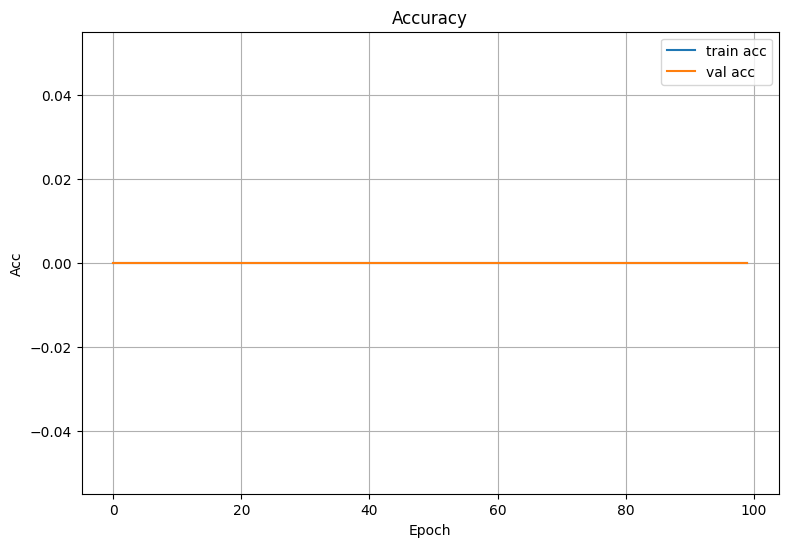

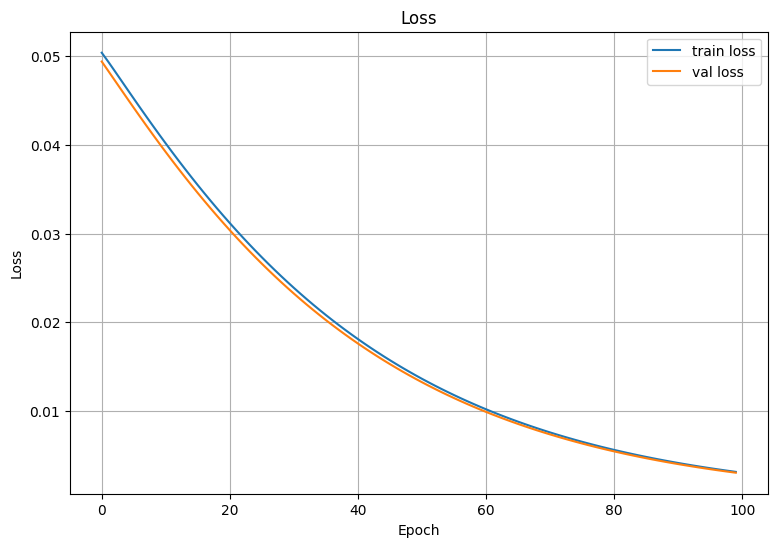

In [39]:
# =========================
# DNN untuk MFCC (end-to-end)
# =========================
import os, sys, math, json, random, pathlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import librosa
import soundfile as sf  # pastikan terpasang
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers, callbacks

# ---------- Konfigurasi ----------
DATA_DIR         = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti ke foldermu
AUDIO_SUBDIR     = "audioanjing"  # atau kosongkan "" jika kelas = subfolder langsung di DATA_DIR
SR               = 22050          # sample rate
N_MFCC           = 40
DURATION         = None           # detik; None = full file
HOP_LENGTH       = 512
CACHE_FEATURES   = True
CACHE_PATH       = "mfcc_features_cache.npz"  # cache supaya ekstraksi tidak mengulang

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# ---------- Util ekstraksi ----------
def extract_mfcc_stats(y, sr, n_mfcc=40, hop_length=512):
    """
    Menghasilkan vektor fitur padat untuk DNN:
      - MFCC (mean, std)
      - Delta MFCC (mean, std)
      - Delta² MFCC (mean, std)
    Panjang fitur = 3 (mfcc, delta, delta2) * 2 (mean,std) * n_mfcc
                  = 6 * n_mfcc (default 240 jika n_mfcc=40)
    """
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)           # (n_mfcc, T)
    d1   = librosa.feature.delta(mfcc)
    d2   = librosa.feature.delta(mfcc, order=2)

    def stats(mat):
        return np.hstack([mat.mean(axis=1), mat.std(axis=1)])  # (2*n_mfcc,)
    feat = np.hstack([stats(mfcc), stats(d1), stats(d2)])      # (6*n_mfcc,)
    return feat

def load_audio(path, sr=22050, duration=None):
    """
    Robust loader; jika gagal dengan soundfile, librosa akan fallback ke audioread.
    """
    y, sr = librosa.load(path, sr=sr, duration=duration, mono=True)
    # Normalisasi kecil agar stabil
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    return y, sr

def collect_audio_files(root, exts=(".wav", ".mp3", ".flac", ".ogg", ".m4a", ".WAV", ".MP3", ".FLAC")):
    root = Path(root)
    files = []
    for p in sorted(root.rglob("*")):
        if p.suffix in exts and p.is_file():
            files.append(p)
    return files

# ---------- Bangun dataset dari folder ----------
def build_dataset_from_dir(data_dir, subdir=""):
    """
    Jika AUDIO_SUBDIR diisi, maka kelas dianggap satu folder (subdir) berisi file-file satu kelas.
    Jika AUDIO_SUBDIR kosong, maka kelas adalah nama subfolder (klasik image-like structure).
    """
    feats = []
    labels = []
    paths  = []

    data_root = Path(data_dir)
    target_root = data_root / subdir if subdir else data_root

    # Mode 1: jika subdir diisi → semua file di folder itu = satu kelas
    if subdir:
        class_names = [subdir]
        files = collect_audio_files(target_root)
        print(f"Menemukan {len(files)} file di {target_root}")
        for i, f in enumerate(files):
            try:
                y, sr = load_audio(str(f), sr=SR, duration=DURATION)
                feat  = extract_mfcc_stats(y, sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
                feats.append(feat)
                labels.append(0)  # kelas tunggal
                paths.append(str(f))
            except Exception as e:
                print("Gagal:", f, e)
    else:
        # Mode 2: kelas = nama subfolder
        class_names = sorted([d.name for d in Path(data_dir).iterdir() if d.is_dir()])
        print("Kelas terdeteksi:", class_names)
        for ci, cname in enumerate(class_names):
            cls_dir = Path(data_dir) / cname
            files = collect_audio_files(cls_dir)
            print(f"[{cname}] {len(files)} file")
            for f in files:
                try:
                    y, sr = load_audio(str(f), sr=SR, duration=DURATION)
                    feat  = extract_mfcc_stats(y, sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
                    feats.append(feat)
                    labels.append(ci)
                    paths.append(str(f))
                except Exception as e:
                    print("Gagal:", f, e)

    X = np.array(feats, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    return X, y, class_names, np.array(paths)

# ---------- Muat atau buat fitur ----------
if CACHE_FEATURES and Path(CACHE_PATH).exists():
    cache = np.load(CACHE_PATH, allow_pickle=True)
    X, y = cache["X"], cache["y"]
    class_names = cache["class_names"].tolist()
    paths = cache["paths"]
    print(f"Memuat cache fitur: {CACHE_PATH} → X:{X.shape}, y:{y.shape}, kelas:{len(class_names)}")
else:
    X, y, class_names, paths = build_dataset_from_dir(DATA_DIR, subdir=AUDIO_SUBDIR)
    if CACHE_FEATURES:
        np.savez_compressed(CACHE_PATH, X=X, y=y, class_names=np.array(class_names, dtype=object), paths=paths)
        print(f"Menyimpan cache fitur ke {CACHE_PATH}")

num_classes = int(np.max(y)) + 1
print("Shape fitur:", X.shape, "| Kelas:", num_classes, class_names)

# ---------- (Jika sudah punya X,y) Split & Scale ----------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

# ---------- Class Weights (opsional tapi disarankan) ----------
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weights)

# ---------- Arsitektur DNN (MLP) ----------
def build_mlp(input_dim, num_classes, l2w=1e-4, drop=0.4, noise_std=0.02):
    inp = layers.Input(shape=(input_dim,))
    x = layers.GaussianNoise(noise_std)(inp)

    for units in [256, 128, 64]:
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=regularizers.l2(l2w))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(drop)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

model = build_mlp(X_train_s.shape[1], num_classes, l2w=1e-4, drop=0.4, noise_std=0.02)
model.summary()

# ---------- Compile ----------
# Pakai loss tanpa label_smoothing agar kompatibel ke TF lama.
adam = optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=adam,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------- Callbacks ----------
cbs = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_dnn_mfcc.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    )
]

# ---------- Train ----------
hist = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,              # EarlyStopping akan stop lebih awal
    batch_size=32,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)

# ---------- Evaluasi ----------
y_val_prob = model.predict(X_val_s)
y_val_pred = np.argmax(y_val_prob, axis=1)

val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc:.4f}\n")
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))

# Confusion matrix (opsional, text)
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion matrix:\n", cm)

# ---------- Plot history ----------
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
plt.plot(hist.history["accuracy"], label="train acc")
plt.plot(hist.history["val_accuracy"], label="val acc")
plt.title("Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(9,6))
plt.plot(hist.history["loss"], label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.title("Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.show()
